<div style="text-align: center; padding: 18px 0;">
  <h1 style="color: #16324f; margin-bottom: 8px;">
    Simulation Monte Carlo pour le pricing d'options
  </h1>
  <h3 style="color: #5c6770; margin-top: 0;">
    Méthode de valorisation sous Black-Scholes en Python
  </h3>
  <p style="color: #8a8f98; font-size: 15px;">
    Projet de finance de marché • Python • Analyse quantitative
  </p>
</div>


<h2 style="color: darkgreen;">Question 1</h2>
Créez une fonction qui télécharge les données historiques d’un stock ou un indice au choix et afficher le
graph de l’évolution du cours sur la période choisie. La librairie yfinance, tirée de yahoo finance, permet de
télécharger les données très facilement en indiquant simplement le ticker (le stock ou l’indice désiré) ainsi
que la plage de date requise.

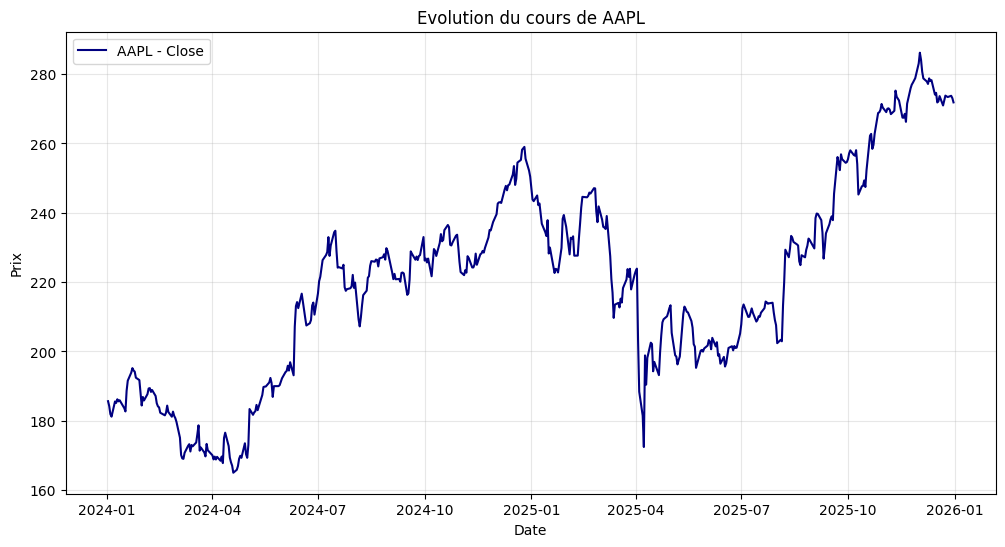

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,,
2024-01-02,183.731277,185.639999,188.440002,183.889999,187.149994,82488700
2024-01-03,182.355591,184.250000,185.880005,183.429993,184.220001,58414500
2024-01-04,180.039673,181.910004,183.089996,180.880005,182.149994,71983600
2024-01-05,179.317169,181.179993,182.759995,180.169998,181.990005,62379700
2024-01-08,183.652130,185.559998,185.600006,181.500000,182.089996,59144500


In [43]:
import matplotlib.pyplot as plt
import yfinance as yf


def telecharger_et_afficher_cours(ticker, date_debut, date_fin, colonne="Close"):
    """Telecharge les donnees Yahoo Finance et trace le cours choisi."""
    donnees = yf.download(
        ticker,
        start=date_debut,
        end=date_fin,
        auto_adjust=False,
        progress=False,
    )

    if donnees.empty:
        raise ValueError(f"Aucune donnee telechargee pour {ticker} sur la periode demandee.")

    if colonne not in donnees.columns:
        raise ValueError(
            f"La colonne '{colonne}' est introuvable. Colonnes disponibles : {list(donnees.columns)}"
        )

    plt.figure(figsize=(12, 6))
    plt.plot(donnees.index, donnees[colonne], label=f"{ticker} - {colonne}", color="navy")
    plt.title(f"Evolution du cours de {ticker}")
    plt.xlabel("Date")
    plt.ylabel("Prix")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    return donnees


# Exemple : Apple entre janvier 2023 et janvier 2024
donnees_aapl = telecharger_et_afficher_cours("AAPL", "2024-01-01", "2026-01-01")
donnees_aapl.head()


La fonction retourne aussi le tableau de donnees telecharge afin de pouvoir reutiliser ces prix dans les prochaines questions du projet.

<h2 style="color: darkgreen;">Question 2</h2>
A partir de la fonction faite dans la question 1, réaliser une fonction calculant les logs returns d’un stock
choisi et affichez les.

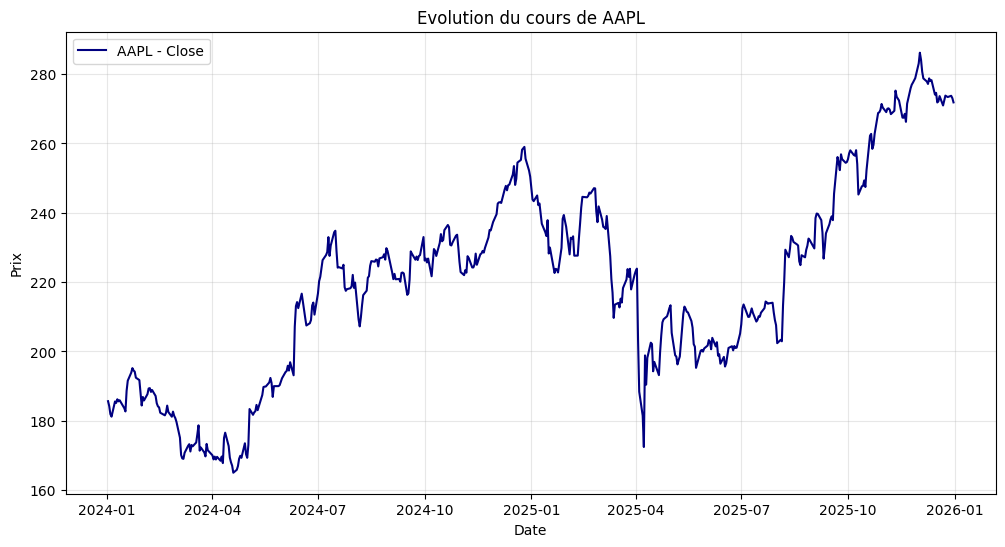

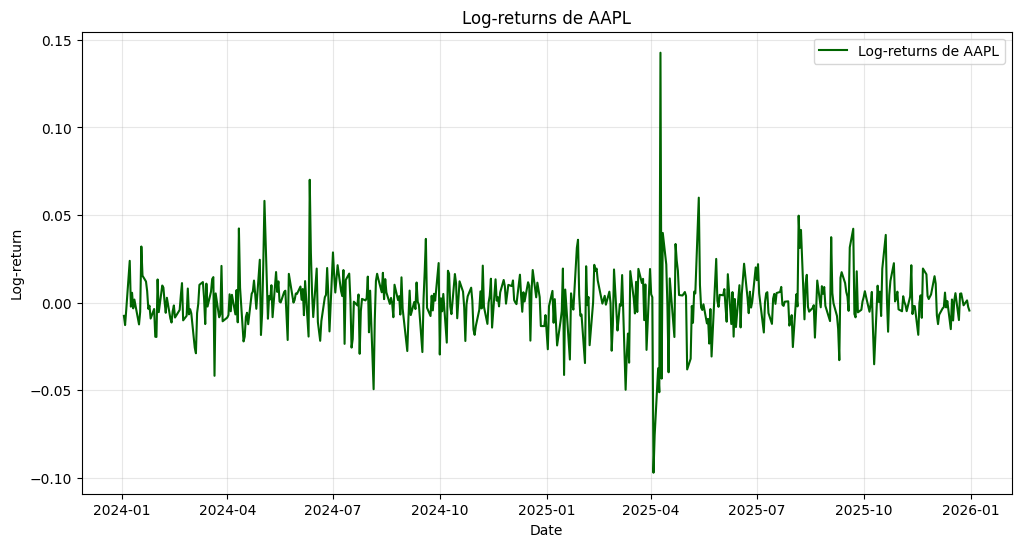

Date
2024-01-03   -0.007516
2024-01-04   -0.012781
2024-01-05   -0.004021
2024-01-08    0.023887
2024-01-09   -0.002266
Name: AAPL, dtype: float64

In [44]:
import numpy as np


def calculer_et_afficher_log_returns(ticker, date_debut, date_fin, colonne="Close"):
    """Calcule et affiche les log-returns a partir des donnees telechargees."""
    donnees = telecharger_et_afficher_cours(ticker, date_debut, date_fin, colonne)

    serie_prix = donnees[colonne]

    if hasattr(serie_prix, "squeeze"):
        serie_prix = serie_prix.squeeze()

    log_returns = np.log(serie_prix / serie_prix.shift(1)).dropna()

    plt.figure(figsize=(12, 6))
    plt.plot(log_returns.index, log_returns, color="darkgreen", label=f"Log-returns de {ticker}")
    plt.title(f"Log-returns de {ticker}")
    plt.xlabel("Date")
    plt.ylabel("Log-return")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    return log_returns


# Exemple d'utilisation
log_returns_aapl = calculer_et_afficher_log_returns("AAPL", "2024-01-01", "2026-01-01")
log_returns_aapl.head()


### Explication des log-returns

Les **log-returns** mesurent la variation relative d'un prix entre deux dates selon la formule :

`log-return = ln(P_t / P_t-1) = ln(P_t) - ln(P_t-1)`

Ils sont tres utilises en finance de marche car ils permettent de travailler plus facilement sur les variations de prix dans le temps. Pour de petites variations, ils sont tres proches des rendements classiques, mais ils ont un avantage important : ils sont **additifs dans le temps**, ce qui simplifie les calculs et l'analyse statistique.

Dans ce projet Monte Carlo, ils sont utiles car ils servent a :

- analyser le comportement historique du sous-jacent ;
- estimer la volatilite du titre ;
- preparer la simulation de trajectoires de prix dans les prochaines questions.

Exemple :  `log-return(03-01-2024) = ln(P(03-01-2024))-ln(P(02-01-2024)) = ln(P(184.250000))-ln(P(185.639999)) `

In [45]:
date_t = "2024-01-03"
date_t_1 = "2024-01-02"

close_series = donnees_aapl["Close"].squeeze()
prix_t = float(close_series.loc[date_t])
prix_t_1 = float(close_series.loc[date_t_1])
log_return_exemple = np.log(prix_t / prix_t_1)

print(
    f"log-return({date_t}) = ln(P({date_t})) - ln(P({date_t_1})) = "
    f"ln(P({prix_t:.6f})) - ln(P({prix_t_1:.6f})) = {log_return_exemple:.6f}"
)


log-return(2024-01-03) = ln(P(2024-01-03)) - ln(P(2024-01-02)) = ln(P(184.250000)) - ln(P(185.639999)) = -0.007516


### Analyse du graphique des log-returns d'APL

Le graphe des log-returns montre que les rendements journaliers de l'action AAPL oscillent globalement autour de `0`, ce qui signifie que les variations quotidiennes sont en moyenne faibles.

La plupart des observations restent proches de zero, tandis que quelques pics positifs et negatifs apparaissent ponctuellement. Ces pics correspondent a des seances de forte hausse ou de forte baisse, souvent liees a des annonces, resultats ou mouvements de marche plus brusques.

On observe aussi que la volatilite n'est pas parfaitement constante dans le temps : certaines periodes sont plus agitees que d'autres. Cette lecture est utile pour la suite du projet, car elle permet d'evaluer le comportement historique du sous-jacent avant de simuler ses trajectoires avec une methode de Monte Carlo.


<h2 style="color: darkgreen;">Question 3</h2>

Créez une fonction qui génère des trajectoires de de Monte Carlo en supposant que le sous-jacent suis un
mouvement brownien géométrique.

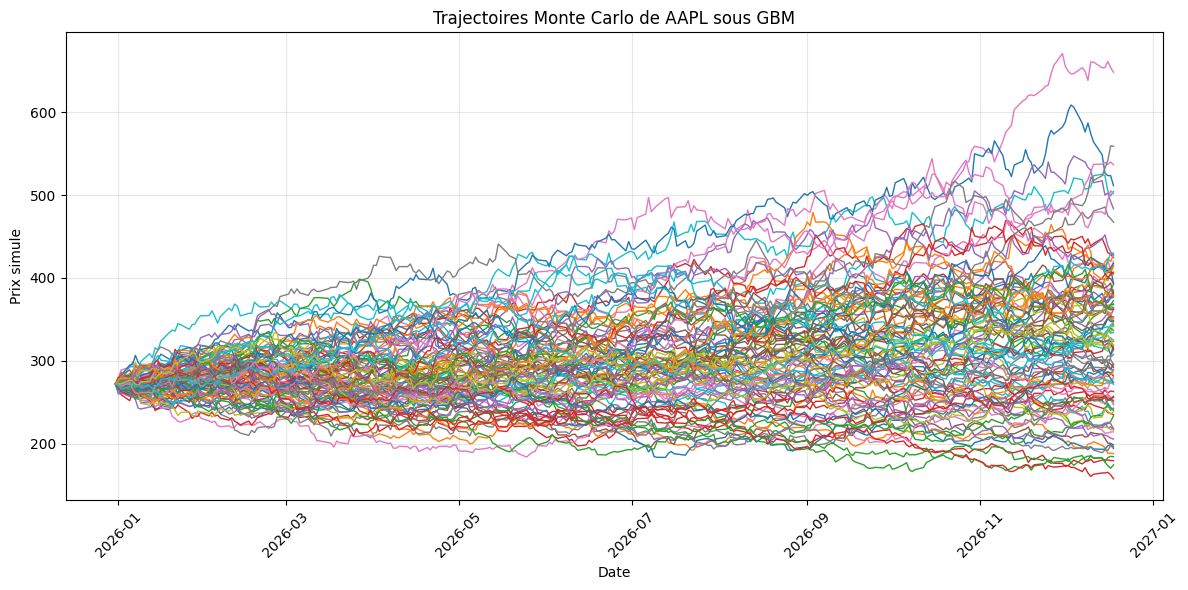

Prix initial : 271.86
Drift annualise estime (mu) : 0.1919
Volatilite annualisee estimee (sigma) : 0.2767


In [46]:
import pandas as pd


def generer_trajectoires_monte_carlo_gbm(prix_initial, mu, sigma, nb_jours=252, nb_trajectoires=100, seed=42):
    """Genere des trajectoires Monte Carlo sous hypothese de mouvement brownien geometrique."""
    np.random.seed(seed)
    dt = 1 / 252

    trajectoires = np.zeros((nb_jours + 1, nb_trajectoires))
    trajectoires[0] = prix_initial

    for t in range(1, nb_jours + 1):
        aleas = np.random.normal(0, 1, nb_trajectoires)
        trajectoires[t] = trajectoires[t - 1] * np.exp(
            (mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * aleas
        )

    return trajectoires


# Estimation des parametres a partir des log-returns historiques
mu_aapl = float(log_returns_aapl.mean() * 252)
sigma_aapl = float(log_returns_aapl.std() * np.sqrt(252))
prix_initial_aapl = float(donnees_aapl["Close"].squeeze().iloc[-1])

# Simulation Monte Carlo
trajectoires_aapl = generer_trajectoires_monte_carlo_gbm(
    prix_initial=prix_initial_aapl,
    mu=mu_aapl,
    sigma=sigma_aapl,
    nb_jours=252,
    nb_trajectoires=100,
)

derniere_date_historique = donnees_aapl.index[-1]
dates_simulation = pd.bdate_range(start=derniere_date_historique, periods=253)

plt.figure(figsize=(12, 6))
plt.plot(dates_simulation, trajectoires_aapl, linewidth=1)
plt.title("Trajectoires Monte Carlo de AAPL sous GBM")
plt.xlabel("Date")
plt.ylabel("Prix simule")
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Prix initial : {prix_initial_aapl:.2f}")
print(f"Drift annualise estime (mu) : {mu_aapl:.4f}")
print(f"Volatilite annualisee estimee (sigma) : {sigma_aapl:.4f}")


### Formule theorique du GBM et lien avec le code

Le modele du **mouvement brownien geometrique** s'ecrit :

$$
dS_t = \mu S_t \, dt + \sigma S_t \, dW_t
$$

ou :

- $S_t$ est le prix de l'actif ;
- $\mu$ est le drift ;
- $\sigma$ est la volatilite ;
- $W_t$ est un mouvement brownien.

En passant au logarithme, on obtient :

$$
d(\ln S_t) = \left(\mu - \frac{1}{2}\sigma^2\right)dt + \sigma \, dW_t
$$

En discretisant sur un petit pas de temps $\Delta t$, on ecrit :

$$
\ln\left(\frac{S_t}{S_{t-1}}\right) = \left(\mu - \frac{1}{2}\sigma^2\right)\Delta t + \sigma\sqrt{\Delta t} \, Z_t
$$

avec :

$$
Z_t \sim \mathcal{N}(0,1)
$$

En exponentiant, on obtient la formule utilisee dans le code :

$$
S_t = S_{t-1} \exp\left[\left(\mu - \frac{1}{2}\sigma^2\right)\Delta t + \sigma\sqrt{\Delta t} \, Z_t\right]
$$

Correspondance avec le code Python :

- $S_t$ correspond a `trajectoires[t]` ;
- $S_{t-1}$ correspond a `trajectoires[t - 1]` ;
- $Z_t$ correspond a `aleas` ;
- $\Delta t = \frac{1}{252}$ correspond a `dt = 1 / 252`.

Autrement dit, a chaque date :

1. on part du prix precedent ;
2. on ajoute une partie deterministe donnee par $\mu$ et $\sigma$ ;
3. on ajoute un choc aleatoire gaussien ;
4. on obtient un nouveau prix simule.


### Interet de la question et du modele GBM

L'interet de cette question est de passer de l'observation historique des rendements a une **simulation de prix futurs**. En finance, la methode de Monte Carlo permet de generer un grand nombre de scenarios possibles pour l'evolution d'un actif. C'est tres utile pour la valorisation d'options, la mesure du risque et l'analyse de differents cas de marche.

Ici, on suppose que le sous-jacent suit un **mouvement brownien geometrique** ou `GBM` (*Geometric Brownian Motion*). C'est un modele classique en finance quantitative, notamment dans Black-Scholes. Il suppose que les rendements suivent une dynamique aleatoire avec :

- une tendance moyenne `mu` appelee drift ;
- une volatilite `sigma` qui mesure l'amplitude des variations ;
- un terme aleatoire qui represente l'incertitude du marche.

L'avantage du GBM est qu'il produit des prix toujours positifs et qu'il donne une base simple et cohérente pour simuler des trajectoires de marche.

### Esperance, variance, ecart-type et volatilite

Dans la cellule precedente, on a vu que le modele GBM s'ecrit en fonction de deux parametres : le drift $\mu$ et la volatilite $\sigma$. Pour comprendre comment on les obtient, il faut revenir aux notions de probabilites appliquees aux **log-returns**.

On definit d'abord le rendement logarithmique entre deux dates par :

$$
r_t = \ln\left(\frac{P_t}{P_{t-1}}\right) = \ln(P_t) - \ln(P_{t-1})
$$

En probabilites, pour une variable aleatoire $X$, l'**esperance** est :

$$
\mathbb{E}[X]
$$

La **variance** mesure la dispersion autour de cette moyenne :

$$
\mathrm{Var}(X) = \mathbb{E}\left[(X - \mathbb{E}[X])^2\right]
$$

et l'**ecart-type** est la racine carree de la variance :

$$
\sigma(X) = \sqrt{\mathrm{Var}(X)}
$$

Dans notre modele de finance, on applique ces definitions a la serie des log-returns $r_t$ :

- l'esperance des $r_t$ represente le rendement moyen ;
- la variance des $r_t$ mesure la dispersion des rendements ;
- l'ecart-type des $r_t$ correspond a la **volatilite**.

La volatilite journaliere s'estime donc par :

$$
\sigma_{\mathrm{journalier}} = \mathrm{std}(r_t)
$$

avec l'estimateur empirique :

$$
\mathrm{std}(r_t) = \sqrt{\frac{1}{N-1}\sum_{t=1}^{N}(r_t - \bar{r})^2}
$$

ou $\bar{r}$ designe la moyenne empirique des log-returns.

Code correspondant dans le notebook :

`log_returns_aapl.std()`

Pour annualiser la volatilite, on utilise :

$$
\sigma_{\mathrm{annuel}} = \sigma_{\mathrm{journalier}} \sqrt{252}
$$

Code correspondant :

`sigma_aapl = log_returns_aapl.std() * np.sqrt(252)`

De la meme facon, le drift annualise est estime par :

$$
\mu_{\mathrm{annuel}} = \mathbb{E}[r_t] \times 252
$$

Code correspondant :

`mu_aapl = log_returns_aapl.mean() * 252`

On obtient donc la correspondance suivante :

- $\mu$ = esperance annualisee des log-returns ;
- $\sigma$ = ecart-type annualise des log-returns ;
- $\sigma^2$ = variance annualisee.

Ces deux quantites estimees sur le passe sont ensuite reinjectees dans la formule du GBM pour simuler les trajectoires futures.

### Analyse succincte du graphique

Le graphique montre un ensemble de trajectoires simulées a partir du meme prix initial. Au debut, les courbes restent proches, puis elles s'ecartent progressivement dans le temps : cela traduit l'effet cumule de l'alea et de la volatilite.

On observe que la dispersion finale est importante, avec certaines trajectoires qui montent fortement et d'autres qui baissent. Cela illustre bien qu'a partir des memes parametres initiaux, plusieurs evolutions de prix sont possibles. Le graphe met donc en evidence l'incertitude sur le futur prix du sous-jacent.

<h2 style="color: darkgreen;">Question 4</h2>
Affichez les simulations de Monte Carlo dans le même graphique que l’évolution des données historique. Il
est judicieux d’utiliser une année comme période globale, pour ne pas nuire à la lisibilité du graph. De
même, générer un (très) nombre faible de trajectoires est une bonne idée pour la même raison. Vous
pouvez choisi les valeurs que vous souhaitez pour mu et sigma.
Tips 1 : Pensez à modifier votre fonction générant des trajectoires de manière à conserver chaque prix
généré et non pas simplement le dernier prix.
Tips 2 : Pensez aux paramètres à employer lors de la génération des trajectoires : les données historiques
fournissent des valeurs journalières. Il faut donc que les trajectoires fournissent un nombre de points
équivalent.

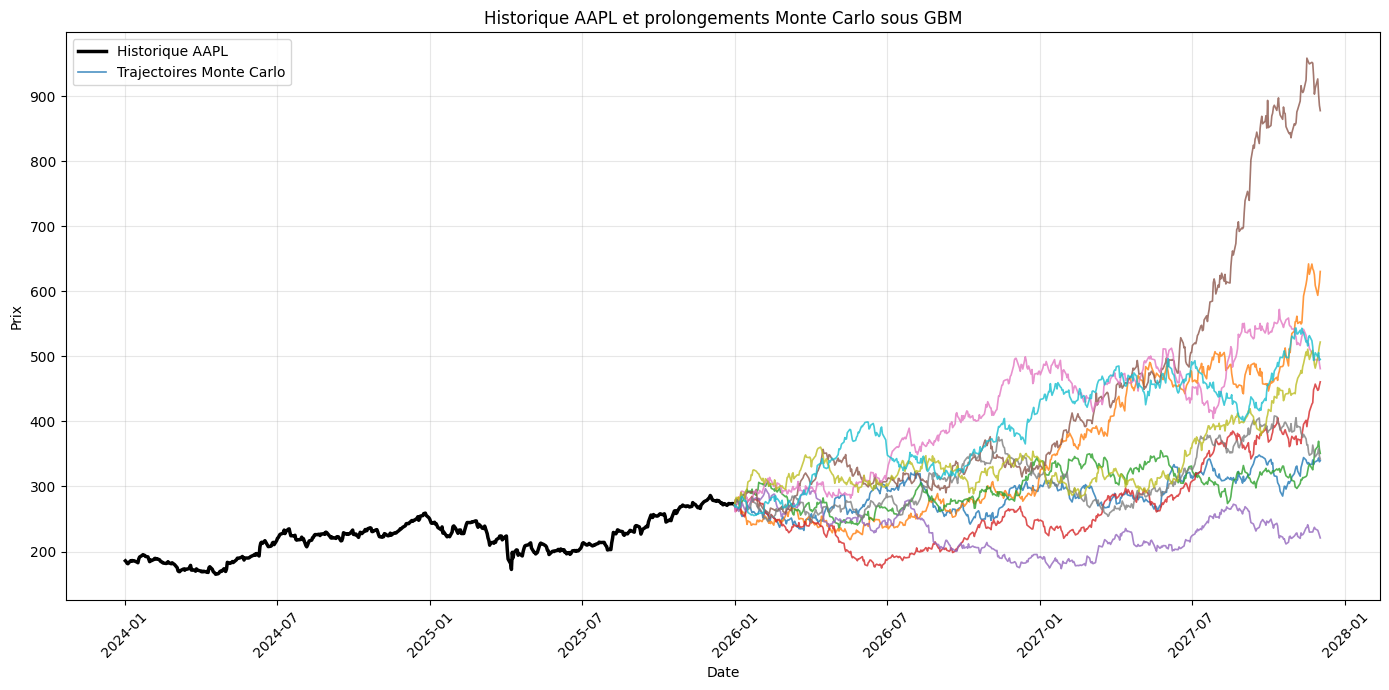

In [47]:
# On se limite a un an d'historique pour garder un graphique lisible
historique_un_an = donnees_aapl["Close"].squeeze().copy()

# Nombre faible de trajectoires pour ne pas surcharger le graphique
nb_trajectoires_q4 = 10
nb_jours_q4 = len(historique_un_an) - 1

# On repart du dernier prix historique pour prolonger la serie
prix_depart_q4 = float(historique_un_an.iloc[-1])

trajectoires_q4 = generer_trajectoires_monte_carlo_gbm(
    prix_initial=prix_depart_q4,
    mu=mu_aapl,
    sigma=sigma_aapl,
    nb_jours=nb_jours_q4,
    nb_trajectoires=nb_trajectoires_q4,
    seed=123,
)

dates_historiques = historique_un_an.index
dates_futures = pd.bdate_range(start=dates_historiques[-1], periods=nb_jours_q4 + 1)

plt.figure(figsize=(14, 7))

# Historique observe
plt.plot(dates_historiques, historique_un_an.values, color="black", linewidth=2.5, label="Historique AAPL")

# Trajectoires simulees
for i in range(nb_trajectoires_q4):
    label = "Trajectoires Monte Carlo" if i == 0 else None
    plt.plot(dates_futures, trajectoires_q4[:, i], linewidth=1.2, alpha=0.8, label=label)

plt.title("Historique AAPL et prolongements Monte Carlo sous GBM")
plt.xlabel("Date")
plt.ylabel("Prix")
plt.grid(True, alpha=0.3)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Contexte, interet de la question et theorie

L'interet de cette question est de **comparer le comportement reel passe du sous-jacent avec des scenarios futurs simules**. Le graphique permet de faire le lien entre les donnees historiques observees et les trajectoires generees par le modele Monte Carlo.

D'un point de vue theorique, on part du dernier prix historique observe, puis on prolonge son evolution avec plusieurs trajectoires simulees sous l'hypothese du **mouvement brownien geometrique (GBM)**. L'idee est de voir comment un meme actif peut evoluer dans le futur selon differents chemins aleatoires, en conservant les parametres estimes sur l'historique, notamment le drift `mu` et la volatilite `sigma`.

Cette superposition est utile car elle permet :

- de visualiser la continuité entre le prix observe et les prolongements possibles ;
- de comparer la dynamique passee avec les scenarios futurs ;
- de mieux comprendre l'incertitude portee par le modele.


### Analyse succincte du graphique

Le graphique montre d'abord l'historique observe de AAPL, puis plusieurs prolongements simules a partir du dernier prix connu. On voit que toutes les trajectoires demarrent du meme point, puis divergent progressivement au fil du temps.

Certaines simulations restent proches de la tendance historique recente, tandis que d'autres s'en ecartent fortement a la hausse ou a la baisse. Cela montre bien qu'a partir d'un meme point de depart, plusieurs evolutions sont possibles. Le graphe illustre donc visuellement l'incertitude sur les prix futurs et l'effet de la volatilite dans le modele.

<h2 style="color: darkgreen;">Question 5</h2>
Que pensez-vous de l’utilisation de valeur « aléatoire » pour mu et sigma ? Pensez-vous à une autre
approche ? Une approche possible consisterait à utiliser les données historiques pour fixer mu et la volatilité
(sigma). Comparez vos résultats en utilisant les données historiques de la période « courte) uniquement
pour trouver mu et sigma : que remarquez-vous et pourquoi ce résultat ?


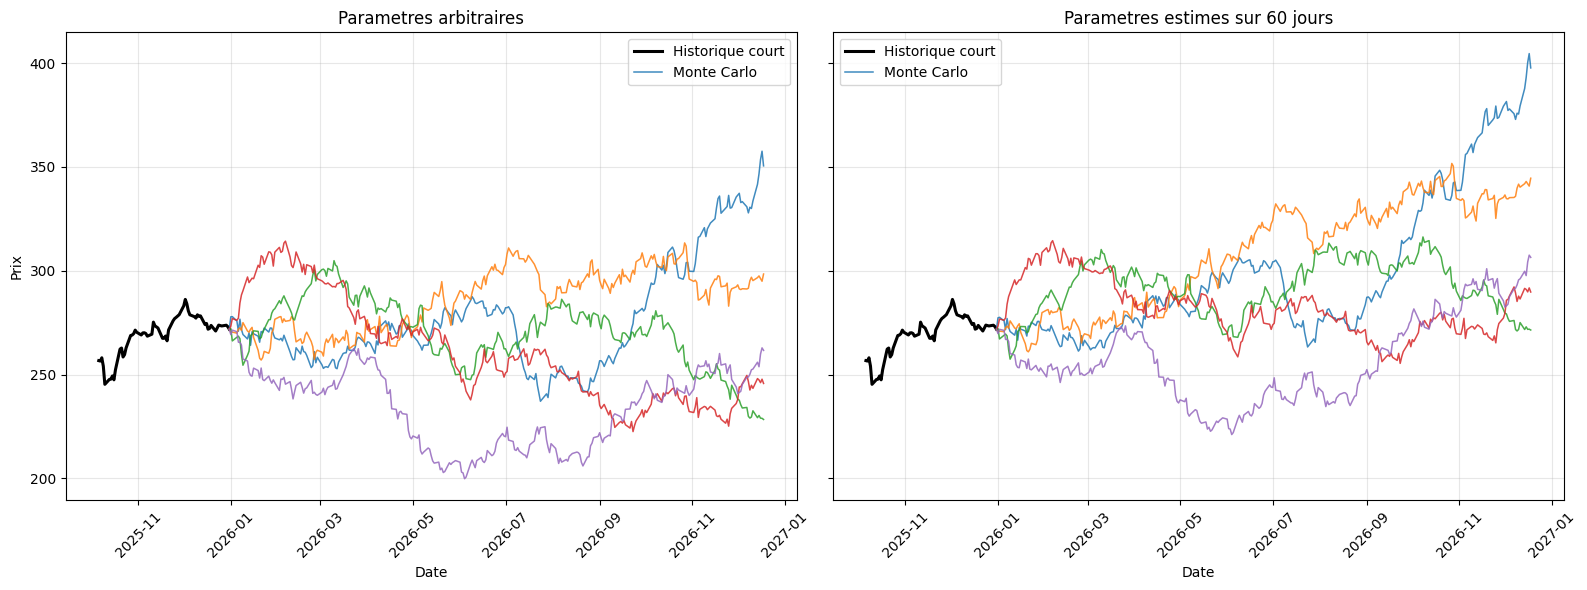

mu aleatoire = 0.1000
sigma aleatoire = 0.2000
mu estime sur 60 jours = 0.2412
sigma estime sur 60 jours = 0.1783


In [48]:
# Hypothese de periode courte : les 60 derniers jours de bourse
periode_courte = 60
historique_court = donnees_aapl["Close"].squeeze().iloc[-(periode_courte + 1):].copy()
log_returns_court = np.log(historique_court / historique_court.shift(1)).dropna()

# Parametres choisis arbitrairement pour comparaison
mu_aleatoire = 0.10
sigma_aleatoire = 0.20

# Parametres estimes sur la periode courte
mu_court = float(log_returns_court.mean() * 252)
sigma_court = float(log_returns_court.std() * np.sqrt(252))

prix_initial_q5 = float(historique_court.iloc[-1])
nb_jours_q5 = 252
nb_trajectoires_q5 = 5

trajectoires_aleatoires = generer_trajectoires_monte_carlo_gbm(
    prix_initial=prix_initial_q5,
    mu=mu_aleatoire,
    sigma=sigma_aleatoire,
    nb_jours=nb_jours_q5,
    nb_trajectoires=nb_trajectoires_q5,
    seed=7,
)

trajectoires_courtes = generer_trajectoires_monte_carlo_gbm(
    prix_initial=prix_initial_q5,
    mu=mu_court,
    sigma=sigma_court,
    nb_jours=nb_jours_q5,
    nb_trajectoires=nb_trajectoires_q5,
    seed=7,
)

dates_hist_q5 = historique_court.index
dates_futures_q5 = pd.bdate_range(start=dates_hist_q5[-1], periods=nb_jours_q5 + 1)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

axes[0].plot(dates_hist_q5, historique_court.values, color="black", linewidth=2.2, label="Historique court")
for i in range(nb_trajectoires_q5):
    label = "Monte Carlo" if i == 0 else None
    axes[0].plot(dates_futures_q5, trajectoires_aleatoires[:, i], alpha=0.85, linewidth=1.1, label=label)
axes[0].set_title("Parametres arbitraires")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Prix")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(dates_hist_q5, historique_court.values, color="black", linewidth=2.2, label="Historique court")
for i in range(nb_trajectoires_q5):
    label = "Monte Carlo" if i == 0 else None
    axes[1].plot(dates_futures_q5, trajectoires_courtes[:, i], alpha=0.85, linewidth=1.1, label=label)
axes[1].set_title("Parametres estimes sur 60 jours")
axes[1].set_xlabel("Date")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

for ax in axes:
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

print(f"mu aleatoire = {mu_aleatoire:.4f}")
print(f"sigma aleatoire = {sigma_aleatoire:.4f}")
print(f"mu estime sur 60 jours = {mu_court:.4f}")
print(f"sigma estime sur 60 jours = {sigma_court:.4f}")


### Contexte, interet de la question et theorie

Cette question sert a montrer que les parametres `mu` et `sigma` influencent directement la forme des trajectoires Monte Carlo. Choisir des valeurs arbitraires peut depanner pour illustrer un modele, mais ce n'est pas la meilleure methode si l'on cherche des scenarios credibles du point de vue financier.

Une approche plus rigoureuse consiste a estimer ces parametres a partir des donnees historiques. Ici, on utilise uniquement une **periode courte** de `60` jours de bourse pour calculer :

- `mu_court = moyenne(r_t) * 252`
- `sigma_court = std(r_t) * sqrt(252)`

On compare donc :

- un modele avec des parametres fixes arbitrairement ;
- un modele calibre sur les rendements recents.

Theoriquement, les parametres estimes sur une periode courte refletent mieux le regime recent du marche, mais ils sont aussi plus sensibles au bruit statistique et aux evenements ponctuels. Les simulations sont donc plus ancrees dans le court terme, mais aussi plus instables.

### Analyse succincte du resultat

Les trajectoires obtenues avec des parametres arbitraires donnent en general un resultat plus "theorique" et parfois deconnecte du comportement recent du titre. A l'inverse, les trajectoires basees sur la periode courte sont davantage influencees par les variations les plus recentes du marche.

Si les deux graphiques sont differents, c'est normal : `mu` et `sigma` changent, donc la pente moyenne et la dispersion des trajectoires changent aussi. Le point important est qu'une estimation sur une periode courte capture mieux l'etat recent du marche, mais peut produire des parametres tres volatils si l'echantillon est petit. Cela montre pourquoi le choix de la fenetre historique est une decision importante en finance.


<h2 style="color: darkgreen;">Question 6 - Bonus</h2>
Créez une classe « Stock » avec pour différentes méthodes les fonctions mentionnées plus
haut ainsi qu’en créant et utilisant judicieusement des attributs de classe. Pensez à adapter vos fonctions si
nécessaires. L’affichage des données peut se faire dans le « main » pour éviter de démultiplier les fonctions
d’affichages. Vous avez désormais une façon simple d’analyser un large nombre de stock en peu de temps : il
vous suffira d’instancier la classe avec votre ticker (et éventuellement vos dates selon vos choix) puis
d’appeler les méthodes pour obtenir des données intéressantes.

In [49]:
class Stock:
    """Classe simple pour analyser un titre financier."""

    def __init__(self, ticker, date_debut, date_fin, colonne="Close"):
        self.ticker = ticker
        self.date_debut = date_debut
        self.date_fin = date_fin
        self.colonne = colonne
        self.donnees = None
        self.log_returns = None
        self.mu = None
        self.sigma = None
        self.trajectoires = None

    def telecharger_donnees(self):
        self.donnees = yf.download(
            self.ticker,
            start=self.date_debut,
            end=self.date_fin,
            auto_adjust=False,
            progress=False,
        )

        if self.donnees.empty:
            raise ValueError(f"Aucune donnee telechargee pour {self.ticker}.")

        return self.donnees

    def afficher_cours(self):
        if self.donnees is None:
            self.telecharger_donnees()

        serie = self.donnees[self.colonne].squeeze()
        plt.figure(figsize=(12, 6))
        plt.plot(serie.index, serie, color="navy", label=f"{self.ticker} - {self.colonne}")
        plt.title(f"Evolution du cours de {self.ticker}")
        plt.xlabel("Date")
        plt.ylabel("Prix")
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

    def calculer_log_returns(self):
        if self.donnees is None:
            self.telecharger_donnees()

        serie = self.donnees[self.colonne].squeeze()
        self.log_returns = np.log(serie / serie.shift(1)).dropna()
        return self.log_returns

    def afficher_log_returns(self):
        if self.log_returns is None:
            self.calculer_log_returns()

        plt.figure(figsize=(12, 6))
        plt.plot(self.log_returns.index, self.log_returns, color="darkgreen", label=f"Log-returns de {self.ticker}")
        plt.title(f"Log-returns de {self.ticker}")
        plt.xlabel("Date")
        plt.ylabel("Log-return")
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

    def estimer_mu_sigma(self, annualisation=252):
        if self.log_returns is None:
            self.calculer_log_returns()

        self.mu = float(self.log_returns.mean() * annualisation)
        self.sigma = float(self.log_returns.std() * np.sqrt(annualisation))
        return self.mu, self.sigma

    def generer_trajectoires_monte_carlo(self, nb_jours=252, nb_trajectoires=100, seed=42):
        if self.donnees is None:
            self.telecharger_donnees()
        if self.mu is None or self.sigma is None:
            self.estimer_mu_sigma()

        np.random.seed(seed)
        dt = 1 / 252
        prix_initial = float(self.donnees[self.colonne].squeeze().iloc[-1])

        self.trajectoires = np.zeros((nb_jours + 1, nb_trajectoires))
        self.trajectoires[0] = prix_initial

        for t in range(1, nb_jours + 1):
            aleas = np.random.normal(0, 1, nb_trajectoires)
            self.trajectoires[t] = self.trajectoires[t - 1] * np.exp(
                (self.mu - 0.5 * self.sigma**2) * dt + self.sigma * np.sqrt(dt) * aleas
            )

        return self.trajectoires

    def afficher_trajectoires_monte_carlo(self, nb_jours=252, nb_trajectoires=100, seed=42):
        if self.trajectoires is None:
            self.generer_trajectoires_monte_carlo(nb_jours=nb_jours, nb_trajectoires=nb_trajectoires, seed=seed)

        derniere_date = self.donnees.index[-1]
        dates_simulation = pd.bdate_range(start=derniere_date, periods=self.trajectoires.shape[0])

        plt.figure(figsize=(12, 6))
        plt.plot(dates_simulation, self.trajectoires, linewidth=1)
        plt.title(f"Trajectoires Monte Carlo de {self.ticker}")
        plt.xlabel("Date")
        plt.ylabel("Prix simule")
        plt.grid(True, alpha=0.3)
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

    def afficher_historique_et_simulation(self, nb_jours=252, nb_trajectoires=10, seed=42):
        if self.donnees is None:
            self.telecharger_donnees()
        self.generer_trajectoires_monte_carlo(nb_jours=nb_jours, nb_trajectoires=nb_trajectoires, seed=seed)

        historique = self.donnees[self.colonne].squeeze()
        dates_hist = historique.index
        dates_futures = pd.bdate_range(start=dates_hist[-1], periods=self.trajectoires.shape[0])

        plt.figure(figsize=(14, 7))
        plt.plot(dates_hist, historique.values, color="black", linewidth=2.2, label=f"Historique {self.ticker}")
        for i in range(nb_trajectoires):
            label = "Monte Carlo" if i == 0 else None
            plt.plot(dates_futures, self.trajectoires[:, i], alpha=0.8, linewidth=1.1, label=label)
        plt.title(f"Historique et simulation Monte Carlo de {self.ticker}")
        plt.xlabel("Date")
        plt.ylabel("Prix")
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()


In [50]:
# Exemple d'utilisation de la classe
aapl = Stock("AAPL", "2023-01-01", "2024-01-01")
aapl.telecharger_donnees()
aapl.calculer_log_returns()
mu_aapl_classe, sigma_aapl_classe = aapl.estimer_mu_sigma()

print(f"mu estime = {mu_aapl_classe:.4f}")
print(f"sigma estime = {sigma_aapl_classe:.4f}")

# Affichages possibles depuis le 'main'
# aapl.afficher_cours()
# aapl.afficher_log_returns()
# aapl.afficher_trajectoires_monte_carlo(nb_jours=252, nb_trajectoires=50)
# aapl.afficher_historique_et_simulation(nb_jours=252, nb_trajectoires=10)


mu estime = 0.4366
sigma estime = 0.1992
